# 我使用了什么库？

In [51]:
# 需要导入的库

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import random
import numpy as np
from PIL import Image

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset, random_split, WeightedRandomSampler, SubsetRandomSampler
from torchvision.transforms.v2 import Compose, ToTensor, Normalize, ToPILImage, RandomHorizontalFlip, Resize, ToImage, ToDtype

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

from data_generation.image_classification import generate_dataset
from plots.chapter4 import *

# 然后，我要干什么？

还是继续研究分类问题，但这次的问题是图像分类，所以还是先要**生成数据**

问题定义: 预测图像属于哪个类,判断图像的中的线是否为对角线？

# 图像分类

## 图像生成

图像信息: 300张图像,每个图像5x5像素

标签定义: 对象线图像是正类,否则是负类


结合代码:

**Q**: 如何创建随机图像?


(300, 1, 5, 5) (300,)
[0 1 1]


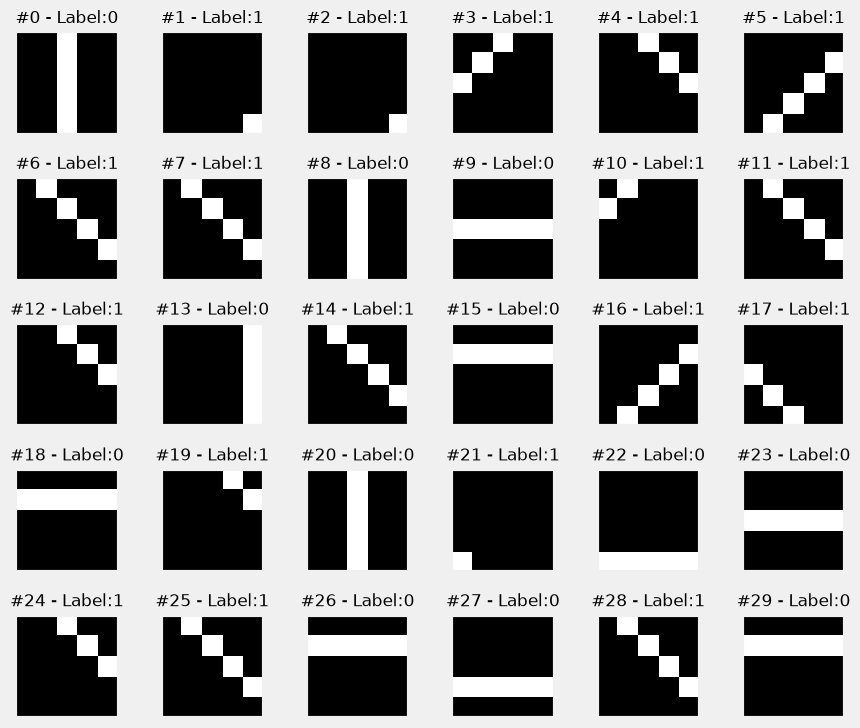

In [52]:
# 图像数据生成

# img大小,n_images是图像数量,seed是种子
images,labels = generate_dataset(img_size=5,n_images=300,binary=True,seed=13)

# 标签的结构
print(images.shape,labels.shape)
print(labels[:3])

# 图像绘制
fig = plot_images(images,labels,n_plot=30)

## 图像格式

**Q**: 在这里，图像是如何表示的？

结合代码:

**Q**: `np.stack`的作用是什么？对向量产生了什么影响？

**Q**: `np`操作中的`axis`究竟是怎么算的？(Tips:数括号,按括号顺序)

**Q**: 解释代码做了什么？

In [53]:
# 程序4-1: axix的用法
print(np.array([
    [[1,2,3],[4,5,6],[7,8,9]],
    [[-1,-2,-3],[-4,-5,-6],[-7,-8,-9]]]).shape)
print(np.stack([
    [[1,2,3],[4,5,6],[7,8,9]],
    [[-1,-2,-3],[-4,-5,-6],[-7,-8,-9]]], axis=2))
print(np.stack([
    [[1,2,3],[4,5,6],[7,8,9]],
    [[-1,-2,-3],[-4,-5,-6],[-7,-8,-9]]], axis=2).shape)

(2, 3, 3)
[[[ 1 -1]
  [ 2 -2]
  [ 3 -3]]

 [[ 4 -4]
  [ 5 -5]
  [ 6 -6]]

 [[ 7 -7]
  [ 8 -8]
  [ 9 -9]]]
(3, 3, 2)


In [54]:
# 为5x5的图像构建三通道
image_r  = np.zeros((5, 5), dtype=np.uint8)
image_r[:, 0] = 255
image_r[:, 1] = 128

image_g = np.zeros((5, 5), dtype=np.uint8)
image_g[:, 1] = 128
image_g[:, 2] = 255
image_g[:, 3] = 128

image_b = np.zeros((5, 5), dtype=np.uint8)
image_b[:, 3] = 128
image_b[:, 4] = 255

print(image_r.shape,image_g.shape,image_b.shape)


(5, 5) (5, 5) (5, 5)


In [55]:
# 计算每个像素的灰度和堆叠出三通道rgb

image_gray = .2126*image_r + .7152*image_g + .0722*image_b
image_rgb = np.stack([image_r, image_g, image_b], axis=2)

print(image_gray.shape,image_rgb.shape)


(5, 5) (5, 5, 3)


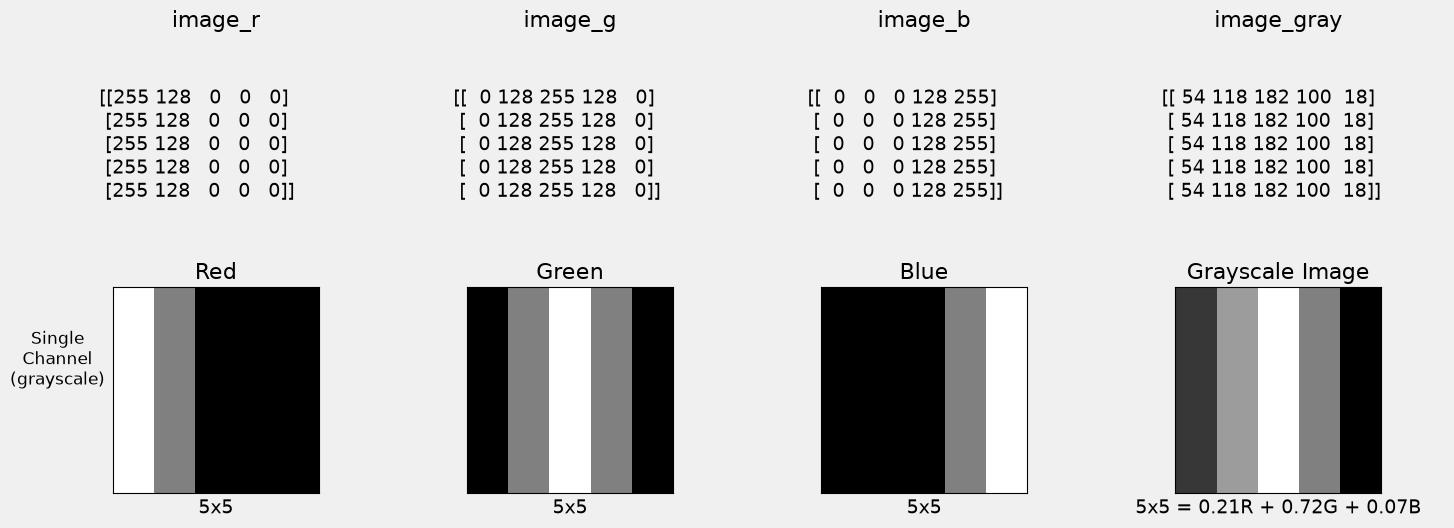

In [56]:
# 可视化灰度
fig = image_channels(image_r, image_g, image_b, image_rgb, image_gray, rows=(0, 1))

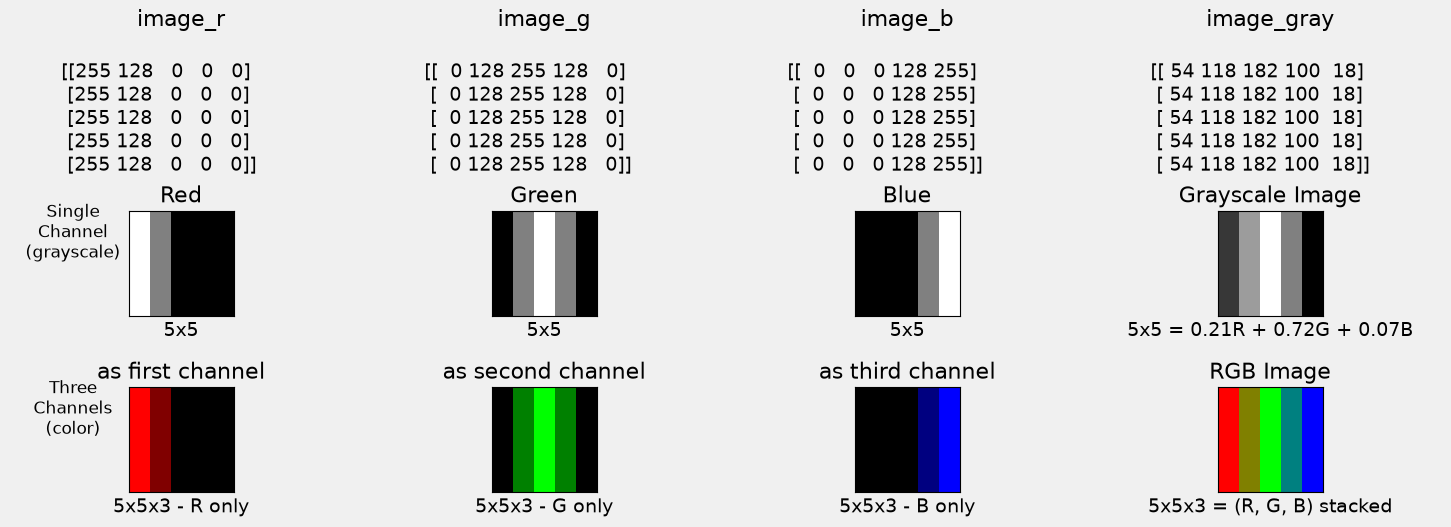

In [57]:
# 可视化三通道rgb

fig = image_channels(image_r, image_g, image_b, image_rgb, image_gray, rows=(0,1,2))

### NCHW 和 NHWC

**Q**: 解释字母的意义，它规定的对象是什么？

**Q**: 各个架构使用的不同结构是什么？（Pytorch,Tensflow,PIL）

结合代码:

**Q**: 解释shape输出的含义

**Q**: 如何转换张量的维度？


In [58]:
# 程序4-2: pytorch使用的结构和内容

print(images.shape)

images7_example = images[7]

print(images7_example.shape)
print(images7_example)

(300, 1, 5, 5)
(1, 5, 5)
[[[  0 255   0   0   0]
  [  0   0 255   0   0]
  [  0   0   0 255   0]
  [  0   0   0   0 255]
  [  0   0   0   0   0]]]


In [59]:
# 程序4-3: 转置分量的位置
example_hwc = np.transpose(images7_example, (1, 2, 0))

# chw vs hwc
print(images7_example.shape,example_hwc.shape)

print(example_hwc)

(1, 5, 5) (5, 5, 1)
[[[  0]
  [255]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [255]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [255]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [255]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]]]


# 然后，我要干什么？

因为涉及图像，需要大致了解`Torchvision`提供的功能，分为:
- 数据集
- 模型
- 转换
    - 基于图像
    - 基于张量
- 归一化
- 组合转换

# TorchVision

## 数据集

**Q**: 除了常见的现成数据集，`ImageFolder`是什么数据集？

## 模型

**Q**: 什么是迁移学习？


## 转换

**Q**: 转换有哪些大类？

**Q**: 数据增强是什么？不适用于什么场景？

结合代码:

**Q**: Image和张量有什么关系？

**Q**: 如何将PIL形状的图像数组转为torch需要的张量？

**Q**: 数组或者说张量中分量的数值范围发生了什么变化？

**Q**: 如何将张量转为PIL图形？

In [60]:
# 程序4-4: 将HWC的Numpy数组变为CHW的张量(老方法: 注意警告)

tmp_tensorizer = ToTensor()

tmp_example_tensor = tmp_tensorizer(example_hwc)

print(tmp_example_tensor.shape)

print(tmp_example_tensor)


torch.Size([1, 5, 5])
tensor([[[0., 1., 0., 0., 0.],
         [0., 0., 1., 0., 0.],
         [0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 1.],
         [0., 0., 0., 0., 0.]]])


d:\moreEnv\anaconda\envs\haienv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [61]:
from torchvision import tv_tensors

# 程序4-4-1: 将HWC的Numpy数组变为CHW的张量（新方法）

# 判断类型
print(example_hwc.shape
      ,isinstance(example_hwc, torch.Tensor)
      ,isinstance(example_hwc, np.ndarray))

# 第一步转为chw的图像
image_tensor = ToImage()(example_hwc)

print(image_tensor.shape
      ,isinstance(image_tensor, torch.Tensor)
      ,isinstance(image_tensor, tv_tensors.Image))

print(image_tensor)

# 第二步转为chw的张量

example_tensor = ToDtype(torch.float32, scale=True)(image_tensor)

print(example_tensor.shape,isinstance(example_tensor, torch.Tensor))

print(example_tensor)


(5, 5, 1) False True
torch.Size([1, 5, 5]) True True
Image([[[  0, 255,   0,   0,   0],
        [  0,   0, 255,   0,   0],
        [  0,   0,   0, 255,   0],
        [  0,   0,   0,   0, 255],
        [  0,   0,   0,   0,   0]]], dtype=torch.uint8, )
torch.Size([1, 5, 5]) True
Image([[[0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0.]]], )


In [62]:
# ps:简易方法

# 还原成example
tmp_example2 = np.transpose(example_hwc,(2, 0, 1))
print(tmp_example2.shape)

print(torch.as_tensor(tmp_example2/255).float().shape)
print(torch.as_tensor(tmp_example2/255).float())

(1, 5, 5)
torch.Size([1, 5, 5])
tensor([[[0., 1., 0., 0., 0.],
         [0., 0., 1., 0., 0.],
         [0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 1.],
         [0., 0., 0., 0., 0.]]])


In [63]:
# 程序4-4-1: 将HWC的Numpy数组变为CHW的张量（利用组合转换合并两步)

def ToTensor():
    return Compose([ToImage(), ToDtype(torch.float32, scale=True)])

tensorizer = ToTensor()
example_tensor = tensorizer(example_hwc)

print(example_tensor.shape)
print(example_tensor)

torch.Size([1, 5, 5])
Image([[[0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0.]]], )


<class 'PIL.Image.Image'>


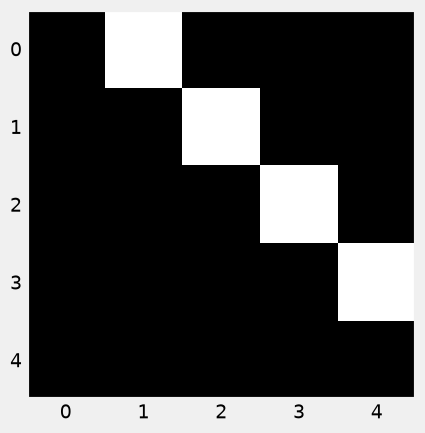

In [64]:
# 程序4-5: 张量转为hwc图片类型（注意不是numpy数组）

# 对于example_hwc的numpy数组同样生效
example_img = ToPILImage()(example_tensor)
print(type(example_img))

# 可视化结果
plt.imshow(example_img, cmap='gray')
plt.grid(False)

### 图像转换和张量转换和归一化

图像操作: `Resize`,`CenterCrop`,`GrayScale`,`RadomHorizontalFlip`,`RandomRotation`

张量操作: `LinearTransformation`,`Normalize`,`RandomEraing`,`ConvertImageDtype`


**Q**: 复习:标准化或者说归一化的作用

**Q**: `Normalize`的操作逻辑是什么？（归一化的对象是谁？）

**Q**: 为什么要标准化？神经网络的训练数据最好有什么样的特征？

**Q**: 标准化的操作和什么操作类似？



结合代码:

**Q**: `RandomHorizontalFlip`的参数是什么意思？

**Q**: 归一化的参数设置为什么要取0.5?

**Q**: 归一化的参数设置的元组形状应该和什么保持一致？




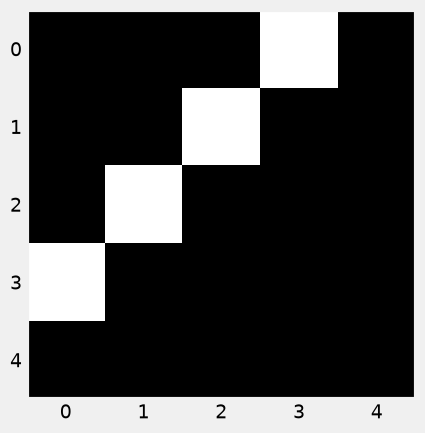

In [65]:
# 程序4-6 图像转换（水平翻转为例）

flipper = RandomHorizontalFlip(p=1)
flipped_img = flipper(example_img)

# 可视化结果
plt.imshow(flipped_img, cmap='gray')
plt.grid(False)

In [66]:
# 程序4-7 张量转换（归一化为例）

# 以翻转图像为数据，先转为张量

img_tensor = tensorizer(flipped_img)

print(img_tensor.shape)
print(img_tensor)

# 归一化
normalizer = Normalize(mean=(.5,), std=(.5,))
normalized_tensor = normalizer(img_tensor)
normalized_tensor

torch.Size([1, 5, 5])
Image([[[0., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]], )


Image([[[-1., -1., -1.,  1., -1.],
        [-1., -1.,  1., -1., -1.],
        [-1.,  1., -1., -1., -1.],
        [ 1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.]]], )

### 组合转换


**Q**: 组合转换的作用？

结合代码:

**Q**: `all`函数是做什么用的？

In [67]:
# 程序4-8 组合转换

composer = Compose([RandomHorizontalFlip(p=1.0),
                    Normalize(mean=(.5,), std=(.5,))])
composed_tensor = composer(example_tensor)


# 验证结果
print((composed_tensor == normalized_tensor).all())



tensor(True)


In [68]:
# 程序4-8-1 all的使用

print((np.array([1,2,3]) == np.array([1,2,3])).all())
print((np.array([1,2,3]) == np.array([1,2,4])).all())


True
False


# 然后，我要干什么？


到此为止，关于都是关于图像操作的介绍，接下来，要顺着流程修改每一步，首先是数据准备的过程
- 对图像要处理为[0,1]的范围
- 数据集肯定不能用之前的TensorDataSet类了
- 对应的loader也得变
- 对于图像，还需要引入**采样器**来处理类别不平衡的问题
- 还需要引入**数据增强**

# 数据准备

In [69]:
# 255->[0,1]的处理

x_tensor = torch.as_tensor(images/255).float()
y_tensor = torch.as_tensor(labels.reshape(-1,1)).float()

## 数据集转换

**Q**: 自定义的数据集和Tensor数据集需要有什么区别？

**Q**: 有没有类似功能的现成DataSet?

结合代码

**Q**: 如何使用自定义的数据集？


In [70]:
# 程序4-9: 自定义图片DataSet
# 注意__init__函数和__getitem__函数的变化
class TransformedTensorDataSet(Dataset):
    def __init__(self,x,y,transform=None):
        self.x = x
        self.y = y
        self.transform = transform
    def __getitem__(self,index):
        x = self.x[index]
        if self.transform:
            x = self.transform(x)
        return x,self.y[index]
    
    def __len__(self):
        return len(self.x)

In [71]:
# 程序4-10: 自定义数据集的使用


composer = Compose([RandomHorizontalFlip(p=0.5),Normalize(mean=(.5,),std=(.5,))])

dataset = TransformedTensorDataSet(x_tensor,y_tensor,composer)

## 采样器

**Q**: 数据加载器中的shuffle参数最终调用的是什么?

**Q**: `RandomSampler`对应哪种情况？

**Q**: `SequentialSampler`对应哪种情况？

**Q**: 采样器的返回是什么？输入是什么？

**Q**: `SubsetRandomSampler`的作用是什么？

结合代码:

**Q**: Sampler和shuffle参数使用时的关系?

**Q**: `index_splitter`存在的意义是什么？返回的是什么？和直接用`random_split`有什么区别？

**Q**: 如何使用采样器切分数据？

**Q**: 如何查看采样器小批量的大小？

In [72]:
# 程序4-11: 拆分数据集

def index_splitter(n, splits, seed=13):
    idx = torch.arange(n)
    # 转为张量
    splits_tensor = torch.as_tensor(splits)
    total = splits_tensor.sum().float()
    # 比如用户指定了训练/验证/测试集的比例为 [0.7, 0.2, 0.2]，总和是 1.1 而不是 1。
    # 这段代码会将它归一化为 [0.636, 0.182,0.182]，确保比例合理。
    if not total.isclose(torch.ones(1)[0]):
        splits_tensor = splits_tensor / total
    
    # pytorch 使用 random_split 拆分索引
    torch.manual_seed(seed)
    return random_split(idx, splits_tensor)

train_idx, val_idx = index_splitter(len(x_tensor), [80, 20])
print(train_idx.indices)

[118, 170, 148, 239, 226, 146, 168, 195, 6, 180, 157, 2, 160, 66, 46, 276, 126, 212, 119, 77, 53, 237, 252, 202, 200, 289, 135, 186, 231, 211, 35, 293, 229, 265, 256, 134, 191, 214, 8, 83, 150, 190, 208, 209, 275, 60, 295, 142, 251, 176, 260, 3, 31, 0, 137, 20, 81, 287, 181, 129, 166, 97, 110, 206, 267, 241, 109, 177, 27, 52, 43, 245, 247, 141, 68, 131, 217, 78, 185, 49, 96, 14, 111, 234, 284, 263, 269, 101, 32, 285, 79, 297, 94, 85, 11, 5, 80, 165, 183, 4, 33, 100, 73, 235, 277, 16, 144, 132, 167, 130, 45, 48, 201, 99, 34, 138, 178, 244, 225, 173, 95, 22, 197, 174, 90, 223, 274, 92, 279, 19, 74, 28, 162, 133, 151, 37, 299, 18, 203, 13, 156, 268, 259, 116, 70, 71, 230, 108, 238, 47, 163, 30, 188, 64, 216, 121, 187, 72, 221, 258, 44, 179, 272, 159, 253, 280, 140, 120, 62, 271, 57, 1, 149, 9, 29, 194, 158, 115, 198, 294, 17, 155, 240, 21, 12, 106, 182, 281, 123, 189, 122, 65, 175, 91, 87, 257, 89, 15, 152, 147, 218, 25, 278, 41, 112, 139, 145, 117, 246, 233, 282, 105, 184, 228, 63, 232, 

In [73]:
# 程序4-11: 拆分数据集

train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)

train_loader = DataLoader(dataset=dataset,batch_size=16,sampler=train_sampler)
val_loader = DataLoader(dataset=dataset,batch_size=16,sampler=val_sampler)


In [74]:
# 程序4-12: 检查采样器批量大小

len(iter(train_loader)),len(iter(val_loader))

(15, 4)

## 数据增强

**Q**: 如果需要数据增强，还能只是用一个数据集嘛？为什么？

代码实现：

**Q**: 如何实现数据增强的数据集？

In [75]:
# 程序4-13: 数据增强


# 使用索引拆分
x_train_tensor = x_tensor[train_idx]
y_train_tensor = y_tensor[train_idx]

x_val_tensor = x_tensor[val_idx]
y_val_tensor = y_tensor[val_idx]


# 数据加强（翻转和缩放）
train_composer = Compose([RandomHorizontalFlip(p=.5),
                          Normalize(mean=(.5,), std=(.5,))])

val_composer = Compose([Normalize(mean=(.5,), std=(.5,))])


# 生成Dataset
train_dataset = TransformedTensorDataSet(x_train_tensor, y_train_tensor, transform=train_composer)
val_dataset = TransformedTensorDataSet(x_val_tensor, y_val_tensor, transform=val_composer)

# 生成Loader
train_loader = DataLoader(dataset=train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=16)



## 不平衡数据集

**Q**: 复习: 到目前为止是如何处理不平衡数据集的？（Tips: 损失）

**Q**: 加权采样器的原理大概是什么样的？

**Q**: 权重如何计算？

**Q**: 替换抽象是什么？


结合代码:

**Q**: `unique`的作用是什么？`return_counts`又是什么？

**Q**: `WeightedRandomSampler`需要什么参数？

In [76]:
# 程序4-14: 权重计算


# 获取类别和对应计数
classes, counts = y_train_tensor.unique(return_counts=True)
print(classes, counts)

# 计算权重
weights = 1.0 / counts.float()
weights

tensor([0., 1.]) tensor([ 80, 160])


tensor([0.0125, 0.0063])

In [77]:
 #程序4-15: 权重序列

sample_weights = weights[y_train_tensor.squeeze().long()]

print(sample_weights.shape)
print(sample_weights[:10])
print(y_train_tensor.shape,y_train_tensor.squeeze().shape)
print(y_train_tensor[:2],y_train_tensor.squeeze()[:2])

torch.Size([240])
tensor([0.0063, 0.0063, 0.0063, 0.0063, 0.0063, 0.0125, 0.0063, 0.0063, 0.0063,
        0.0063])
torch.Size([240, 1]) torch.Size([240])
tensor([[1.],
        [1.]]) tensor([1., 1.])


In [78]:
#程序4-16: WeighttedRandomSampler使用

generator = torch.Generator()

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    generator=generator,
    replacement=True # 设置是否放回抽样
)

train_loader = DataLoader(dataset=train_dataset, batch_size=16, sampler=sampler)
val_loader = DataLoader(dataset=val_dataset, batch_size=16)


In [79]:
#程序4-17: 不平衡数据的处理
def make_balanced_sampler(y):
    # 计算权重
    classes,counts = y.unique(return_counts=True)
    weights = 1.0 / counts.float()
    sample_weights = weights[y.squeeze().long()]
    # 使用权重构建采样器
    generator = torch.Generator()
    sampler = WeightedRandomSampler(
        weights = sample_weights,
        num_samples = len(sample_weights),
        generator = generator,
        replacement = True
    )
    return sampler

sampler = make_balanced_sampler(y_train_tensor)

## 种子和生成器

结合代码:

**Q**: 如何设置种子? 

**Q**: python的random为什么出现在这里？



In [80]:
#程序4-17: 设置种子

train_loader.sampler.generator.manual_seed(42)
random.seed(42)

# 验证结果
# 看抽样个数是否为总数一半左右？
print(torch.tensor([t[1].sum() for t in iter(train_loader)]).sum())

tensor(123.)


In [81]:
#程序4-18: 设置种子的方法
from StepClass.v0 import StepByStep

def set_seed(self, seed=42):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False    
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    try:
        self.train_loader.sampler.generator.manual_seed(seed)
    except AttributeError:
        pass
    
setattr(StepByStep, 'set_seed', set_seed)

In [82]:
# 程序4-19: 数据准备

# 像素内容转换

x_tensor = torch.as_tensor(images/255).float()
y_tensor = torch.as_tensor(labels.reshape(-1,1)).float()

# 索引拆分
train_idx,val_idx = index_splitter(len(x_tensor),[80,20])

# 利用索引拆分数据
x_train_tensor = x_tensor[train_idx]
y_train_tensor = y_tensor[train_idx]
x_val_tensor = x_tensor[val_idx]
y_val_tensor = y_tensor[val_idx]


# 数据增强
train_composer = Compose([RandomHorizontalFlip(p=.5),Normalize(mean=(.5,),std=(.5,))])
val_composer = Compose([Normalize(mean=(.5,),std=(.5,))])

# 构建数据集
train_dataset =TransformedTensorDataSet(x_train_tensor,y_train_tensor,transform=train_composer)
val_dataset =TransformedTensorDataSet(x_val_tensor,y_val_tensor,transform=val_composer)


# 构建权重采样器

sampler = make_balanced_sampler(y_train_tensor)


# 获得平衡数据的loader
train_loader = DataLoader(dataset=train_dataset,batch_size=16,sampler=sampler)
val_loader = DataLoader(dataset=val_dataset,batch_size=16)

## 像素作为特征

**Q**: 如果把像素展平，会丢失信息嘛？

结合代码：

**Q**: 如何展平一个小批量的数据？

In [83]:
# 程序4-20: 如何展平一个批量的数据

# 加载小批量
dummy_xs, dummy_ys = next(iter(train_loader))
print(dummy_xs.shape)


# 展平
flattener = nn.Flatten()
dummy_xs_flat = flattener(dummy_xs)

print(dummy_xs_flat.shape)
print(dummy_xs_flat[0])

torch.Size([16, 1, 5, 5])
torch.Size([16, 25])
tensor([-1., -1., -1.,  1., -1., -1., -1., -1.,  1., -1., -1., -1., -1.,  1.,
        -1., -1., -1., -1.,  1., -1., -1., -1., -1.,  1., -1.])


# 然后，我要干什么？

目前为止，已经完成了数据准备，接下来是模型配置和模型训练的部分

首先，将尝试没有隐藏层的情况下的表现

接着，再尝试添加两个额外线性层后的表现

然后，将通过数学和可视化的方法分析原因

最后，引出激活函数的作用

# 浅层模型

**Q**: 这样的模型表现如何？

结合代码:

**Q**: 复习: 模型配置和模型训练的使用

In [84]:
# 程序4-21: 模型配置

lr = 0.1

torch.manual_seed(17)

# 模型
model_logistic = nn.Sequential()

model_logistic.add_module("flatten",nn.Flatten())
model_logistic.add_module("ouput",nn.Linear(25,1,bias=False))
model_logistic.add_module("sigmoid",nn.Sigmoid())


# 优化器
optimizer_logistic = optim.SGD(model_logistic.parameters(),lr=lr)

# 损失函数
binary_loss_fn = nn.BCELoss()


In [85]:
# 程序4-22: 模型训练

n_epochs = 100

sbs_logistic = StepByStep(model_logistic, binary_loss_fn, optimizer_logistic)
sbs_logistic.set_loaders(train_loader, val_loader)
sbs_logistic.train(n_epochs)


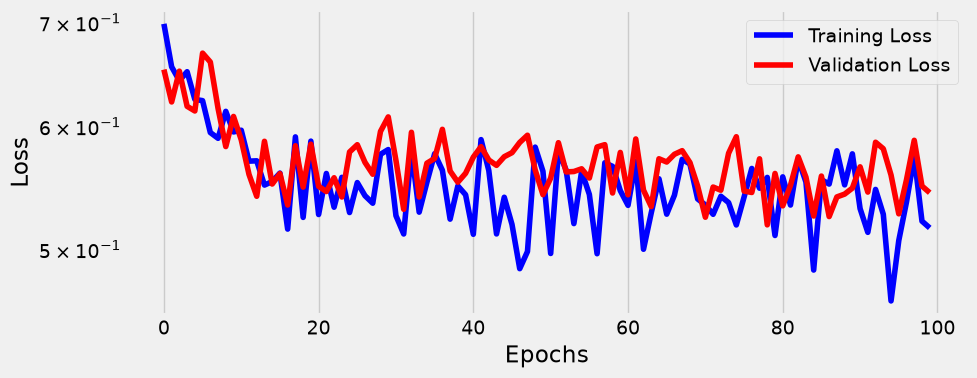

In [86]:
# 可视化结果
fig = sbs_logistic.plot_losses()

# 深层模型

**Q**: 这样的模型表现如何？

结合代码:

**Q**: 复习: 模型配置和模型训练的使用

In [87]:
# 程序4-23: 模型配置

lr = 0.1

torch.manual_seed(17)

# 模型
model_nn = nn.Sequential()

model_nn.add_module("flatten",nn.Flatten())
model_nn.add_module("hidden0",nn.Linear(25,5,bias=False))
model_nn.add_module("hidden1",nn.Linear(5,3,bias=False))
model_nn.add_module("ouput",nn.Linear(3,1,bias=False))
model_nn.add_module("sigmoid",nn.Sigmoid())


# 优化器
optimizer_nn = optim.SGD(model_nn.parameters(),lr=lr)

# 损失函数
binary_loss_fn = nn.BCELoss()


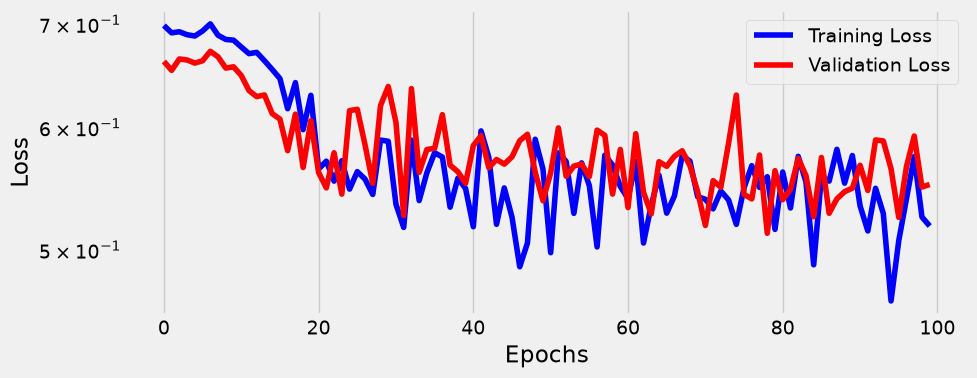

In [88]:
# 程序4-24: 模型训练

n_epochs = 100

sbs_nn = StepByStep(model_nn, binary_loss_fn, optimizer_nn)
sbs_nn.set_loaders(train_loader, val_loader)
sbs_nn.train(n_epochs)

# 可视化结果
fig = sbs_nn.plot_losses()

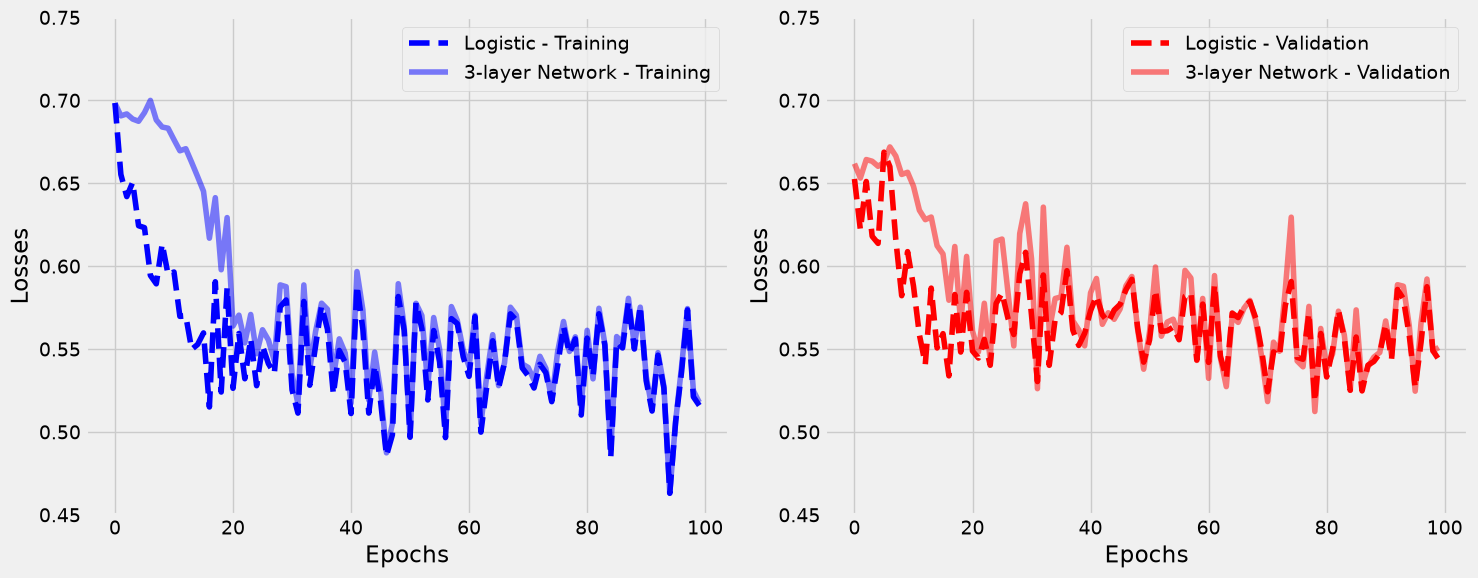

In [89]:
# 和纯逻辑回归比较
fig = figure5(sbs_logistic, sbs_nn)

# 发生了什么？

**Q**: 激活函数是什么？有什么作用？

**Q**: 激活函数有哪些种类？（3个）

**Q**: 为什么没有激活函数的深层模型等效于逻辑回归？

**Q**: 为什么使用同样种子的模型初始化不一定一样？

结合代码:

**Q**: 验证没有激活函数的深层模型等效于逻辑回归这个结论

**Q**: `@`是什么操作？

**Q**: 如何统计模型参数的数量？

**Q**: `numel`是什么函数？



torch.Size([5, 25]) torch.Size([3, 5]) torch.Size([1, 3])
torch.Size([1, 25])
torch.Size([1, 25])


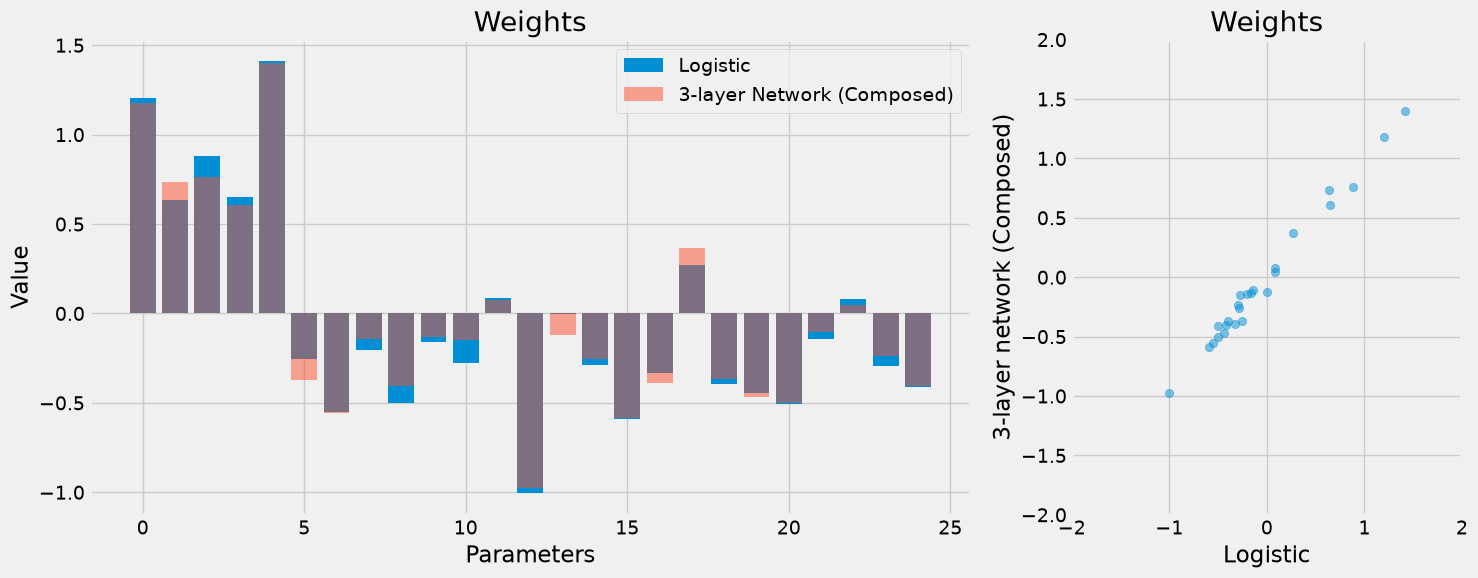

In [90]:
# 程序4-25 验证没有激活函数的深层模型等效于逻辑回归

# 展示每一层的维度
w_nn_hidden0 = model_nn.hidden0.weight.detach()
w_nn_hidden1 = model_nn.hidden1.weight.detach()
w_nn_output = model_nn.ouput.weight.detach()

print(w_nn_hidden0.shape, w_nn_hidden1.shape, w_nn_output.shape)

# 合并中间层(矩阵乘法)
w_nn_equiv = w_nn_output @ w_nn_hidden1 @ w_nn_hidden0
print(w_nn_equiv.shape)

# 等效@操作
w_nn_equiv = w_nn_output.mm(w_nn_hidden1.mm(w_nn_hidden0))

# 和逻辑回归比较
w_logistic_output = model_logistic.ouput.weight.detach()

print(w_logistic_output.shape)

# 可视化结果

fig = weights_comparison(w_logistic_output, w_nn_equiv)

In [91]:
# 程序4-26 统计参数个数

def count_parameters(self):
    return sum(p.numel() for p in self.model.parameters() if p.requires_grad)

setattr(StepByStep, 'count_parameters', count_parameters)

# 验证结果
sbs_logistic.count_parameters(), sbs_nn.count_parameters()

(25, 143)

## 可视化权重

**Q**: 如何可视化权重？

**Q**: 什么是滤波器？

结合代码：

**Q**: 实现的图像和真实的滤波器有什么区别?


torch.Size([5, 25])


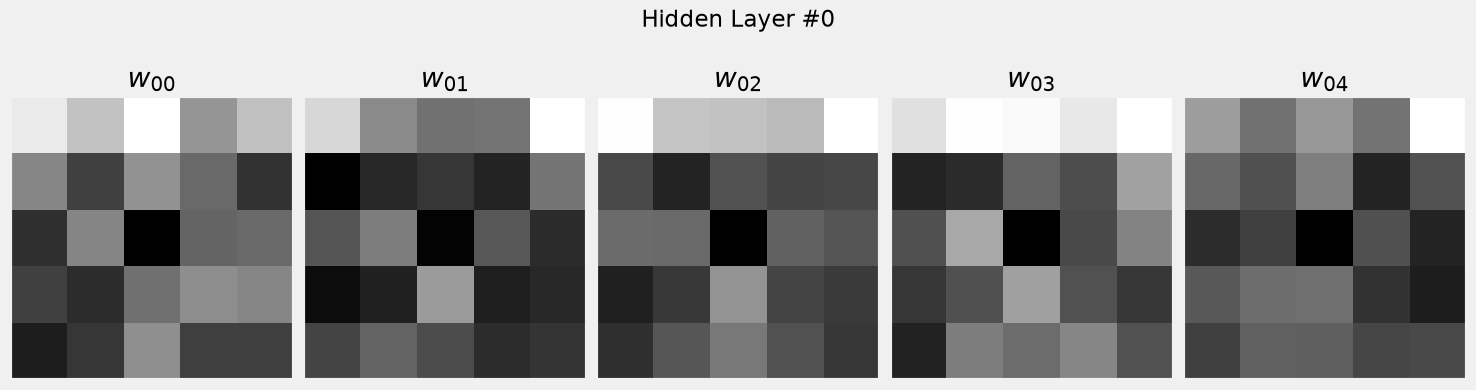

In [92]:
# 可视化权重
print(w_nn_hidden0.shape)
fig = figure7(w_nn_hidden0)

# 激活函数

**Q**: 什么是激活函数？

**Q**: 激活函数的作用是什么？

**Q**: 激活函数的是否为线性？

**Q**: 激活函数有哪几种？（5个）

结合代码和图片:

**Q**: 几种激活函数直观上对线性曲线的影响？

**Q**: 激活值是否以0为中心影响了什么？Sigmoid以什么为中心？

**Q**: Sigmoid和TanH的梯度都有什么特点？以什么为中心？

**Q**: RELU有什么特点和缺点？以什么为中心？

**Q**: 泄露ReLU是什么？有什么特点？

**Q**: 参数ReLU是什么？

**Q**: 几种函数的公式和使用？



d:\projectCode\AI\PyTorchStepByStep\plots\chapter4.py:175: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


tensor([0.0474, 0.5000, 0.9526])
tensor([0.0474, 0.5000, 0.9526])


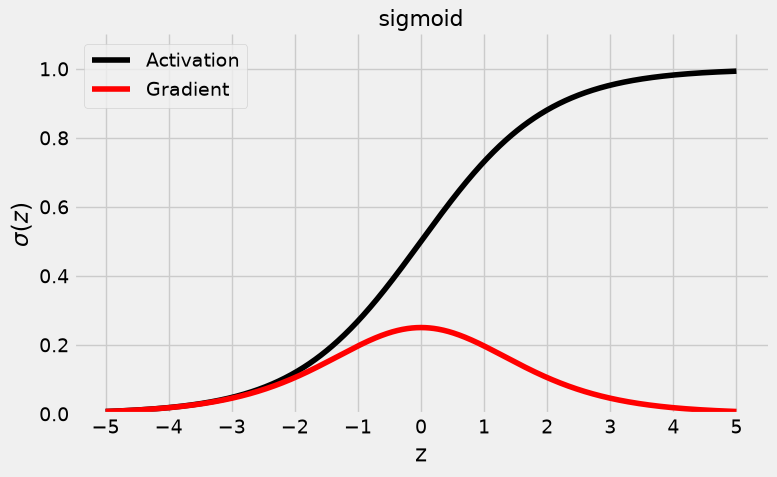

In [93]:
# 程序4-27 SigMoid

fig = plot_activation(torch.sigmoid)
dummy_z = torch.tensor([-3., 0., 3.])


print(torch.sigmoid(dummy_z))
print(nn.Sigmoid()(dummy_z))


tensor([-0.9951,  0.0000,  0.9951])
tensor([-0.9951,  0.0000,  0.9951])


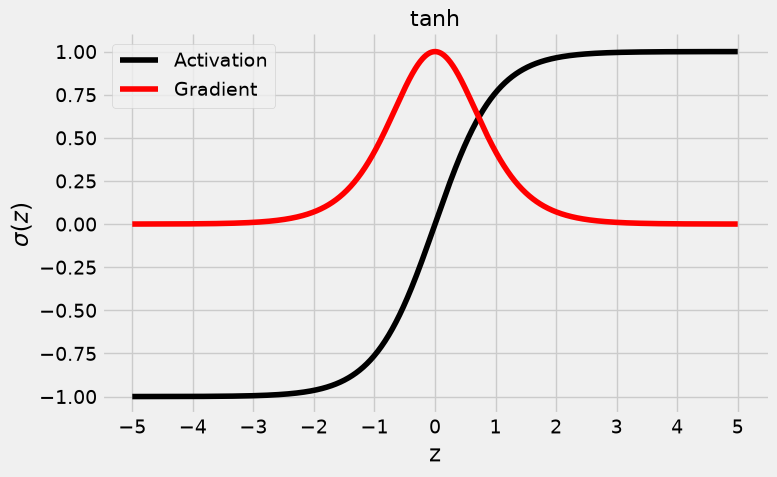

In [94]:
# 程序4-28 TanH

fig = plot_activation(torch.tanh)
dummy_z = torch.tensor([-3., 0., 3.])

print(torch.tanh(dummy_z))
print(nn.Tanh()(dummy_z))

tensor([0., 0., 3.])
tensor([0., 0., 3.])
tensor([0., 0., 3.])


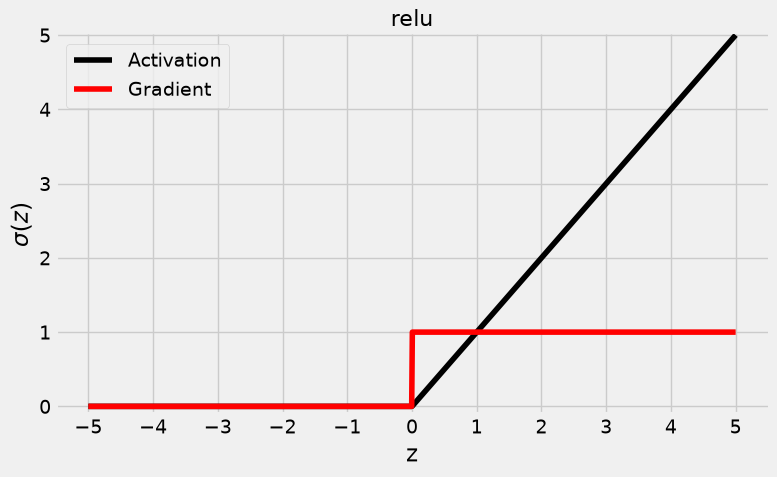

In [95]:
# 程序4-29 ReLU

fig = plot_activation(torch.relu)
dummy_z = torch.tensor([-3., 0., 3.])

print(F.relu(dummy_z))
print(nn.ReLU()(dummy_z))
print(dummy_z.clamp(min=0))

tensor([-0.0300,  0.0000,  3.0000])
tensor([0., 0., 3.])
tensor([-0.0600,  0.0000,  3.0000])


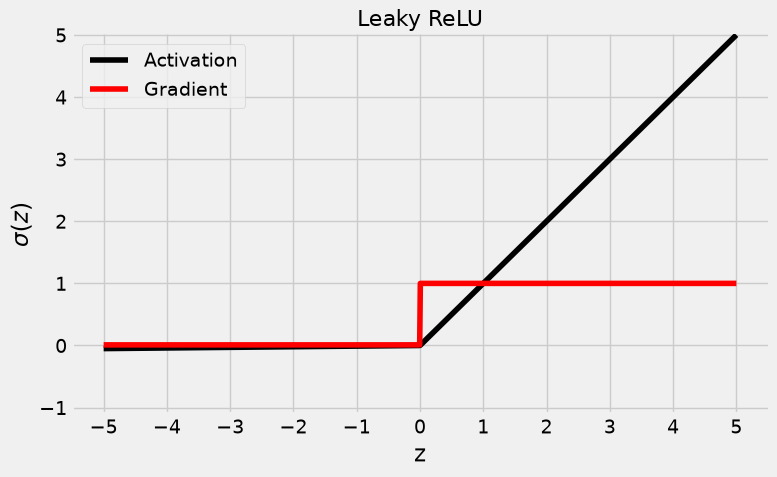

In [96]:
# 程序4-30 泄露ReLU

fig = plot_activation(nn.LeakyReLU(), name='Leaky ReLU')
dummy_z = torch.tensor([-3., 0., 3.])


print(F.leaky_relu(dummy_z, negative_slope=0.01))
print(dummy_z.clamp(min=0))
print(nn.LeakyReLU(negative_slope=0.02)(dummy_z))

tensor([-0.7500,  0.0000,  3.0000])
tensor([-0.7500,  0.0000,  3.0000], grad_fn=<PreluKernelBackward0>)


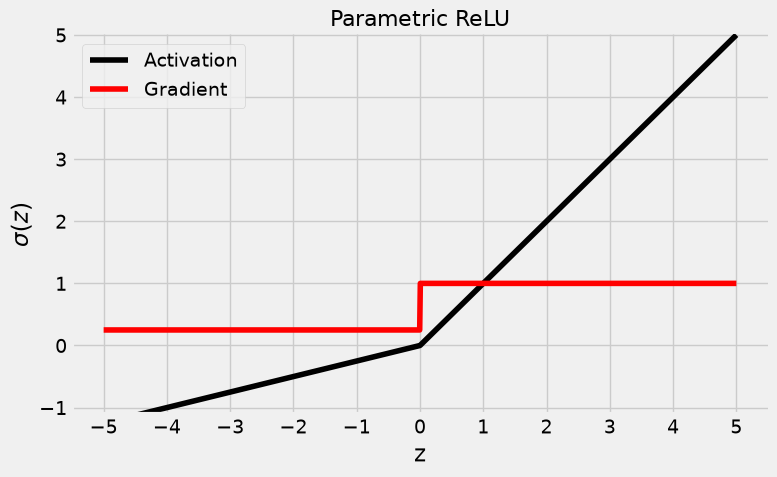

In [97]:
# 程序4-31 参数ReLU

fig = plot_activation(nn.PReLU(), name='Parametric ReLU')
dummy_z = torch.tensor([-3., 0., 3.])


print(F.prelu(dummy_z, weight=torch.tensor(0.25)))
print(nn.PReLU(init=0.25)(dummy_z))

# 然后，我要干什么？

到此为止，模型配置和训练存在的问题就解决了，现在将及部分拼起来，验证下效果

# 深度模型

结合代码:

**Q**: nn.Linear中的bias控制的是什么？

In [98]:
# 程序4-32 模型配置

lr = 0.1

torch.manual_seed(17)

model_relu = nn.Sequential()
model_relu.add_module('flatten', nn.Flatten())
model_relu.add_module('hidden0', nn.Linear(25, 5, bias=False))
model_relu.add_module('activation0', nn.ReLU())
model_relu.add_module('hidden1', nn.Linear(5, 3, bias=False))
model_relu.add_module('activation1', nn.ReLU())
model_relu.add_module('output', nn.Linear(3, 1, bias=False))
model_relu.add_module('sigmoid', nn.Sigmoid())


optimizer_relu = optim.SGD(model_relu.parameters(), lr=lr)


binary_loss_fn = nn.BCELoss()

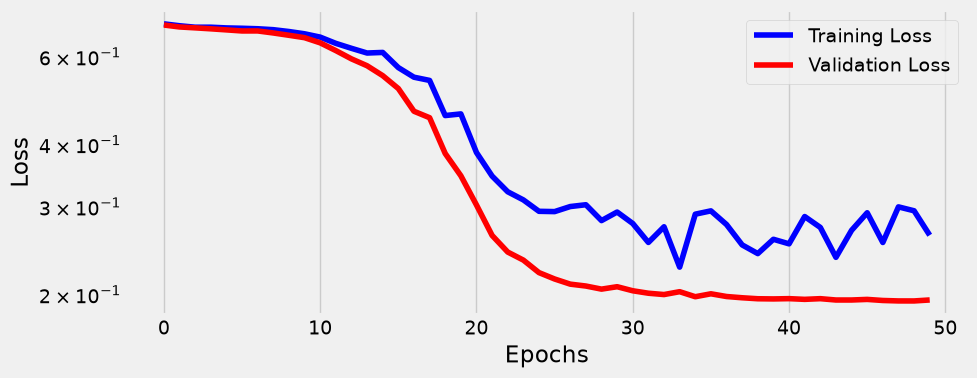

In [99]:
# 程序4-33 模型配置

n_epochs = 50

sbs_relu = StepByStep(model_relu,binary_loss_fn,optimizer_relu)
sbs_relu.set_loaders(train_loader,val_loader)
sbs_relu.train(n_epochs)

fig = sbs_relu.plot_losses()

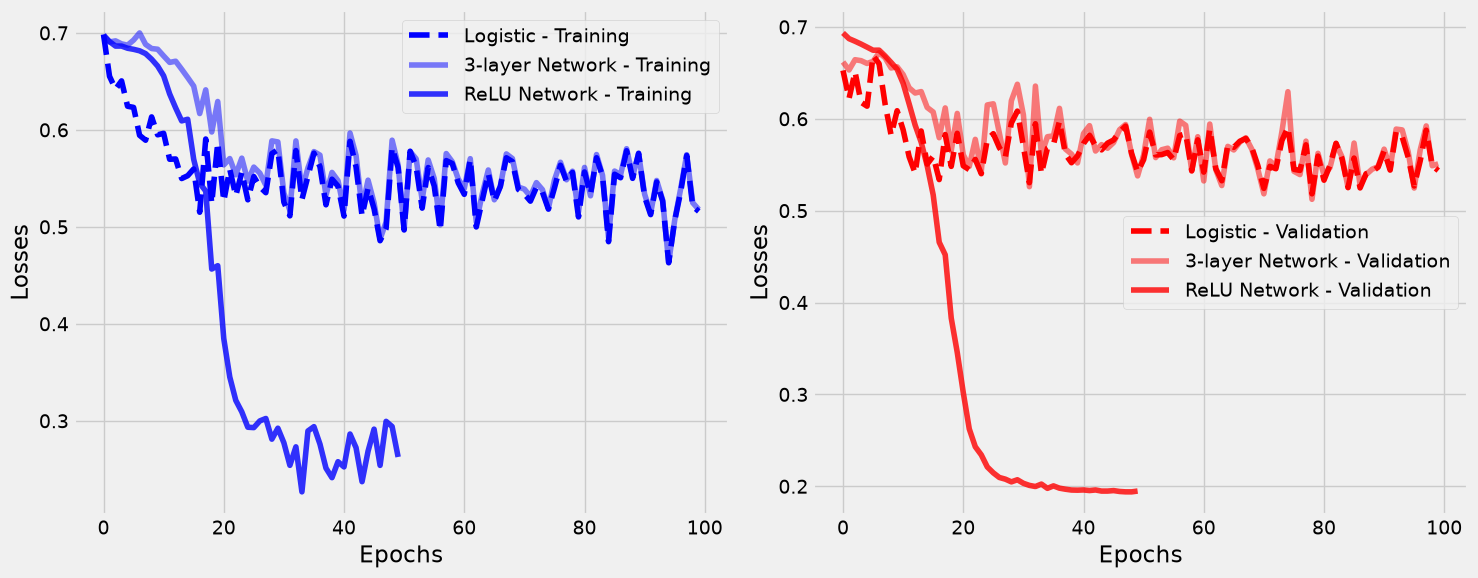

In [100]:
# 对比结果
fig = figure5b(sbs_logistic, sbs_nn, sbs_relu)